# Análise dados Referentes à Educação

In [2]:
#Importando os dados
import pandas as pd
tabela = pd.read_csv("../data/Exam_Score_Prediction.csv")
tabela.head(10)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
5,6,23,male,b.tech,3.48,65.4,yes,4.2,good,mixed,low,moderate,58.2
6,7,17,female,b.tech,1.35,69.0,yes,7.4,average,online videos,high,hard,53.7
7,8,22,male,b.sc,5.48,51.1,yes,8.2,poor,self-study,low,moderate,47.3
8,9,18,other,bca,2.89,92.0,yes,6.6,poor,self-study,low,easy,44.9
9,10,17,male,bba,6.77,44.8,yes,9.8,average,group study,high,moderate,77.7


### Estimando Regressão

In [7]:
import statsmodels.api as sm
y = tabela["exam_score"]
x = tabela[["age", "study_hours", "class_attendance", "sleep_hours"]]

# No python, precisa adicionar a constante manualmente
x = sm.add_constant(x)

# Estimando a regressão
modelo = sm.OLS(y,x).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     8488.
Date:                Sat, 10 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:03:46   Log-Likelihood:                -77245.
No. Observations:               20000   AIC:                         1.545e+05
Df Residuals:                   19995   BIC:                         1.545e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.6543      0.878  

### Criando Gráficos

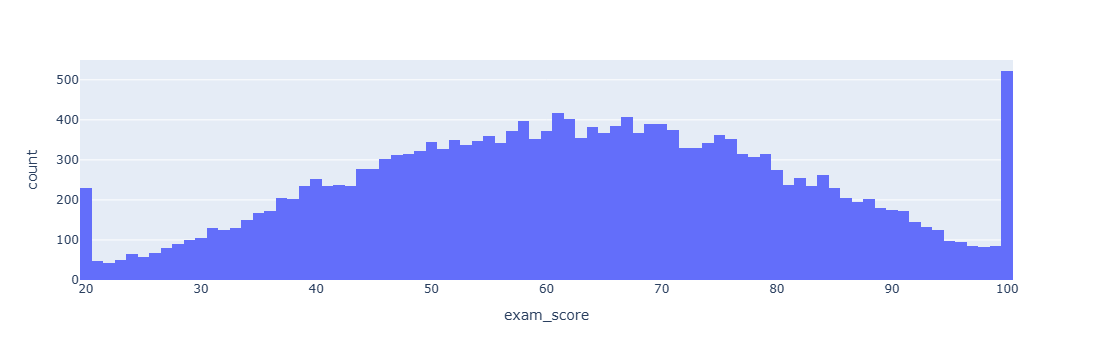

In [20]:
px.histogram(tabela, x="exam_score")

0.7177879939079729


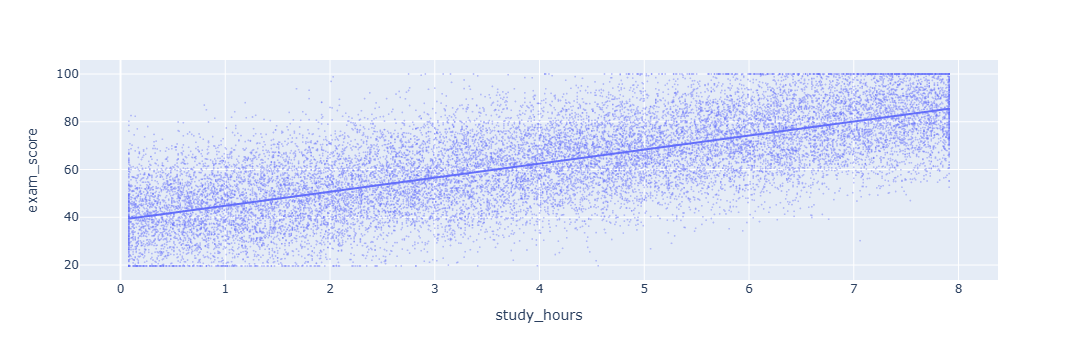

0.308850270055646


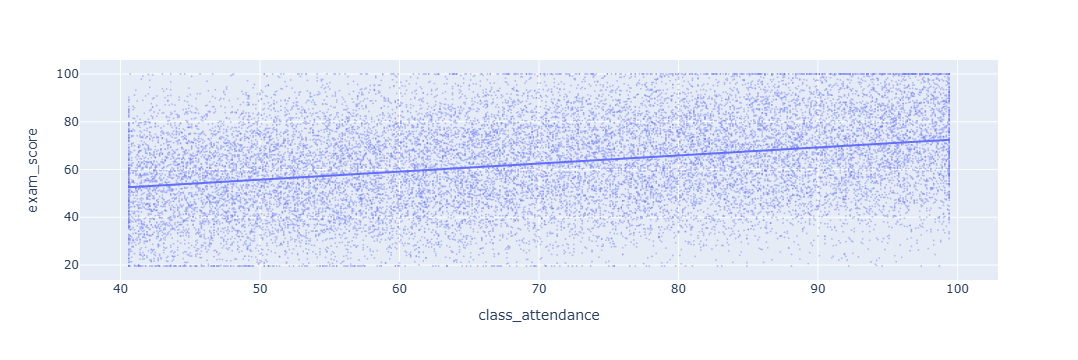

0.13322174783646304


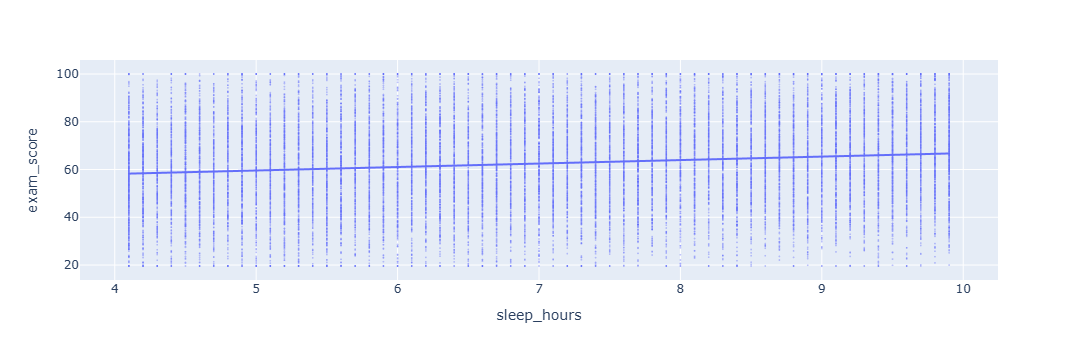

In [50]:
numericas = ["study_hours", "class_attendance", "sleep_hours"]

for coluna in numericas:
    x = pd.Series(tabela[coluna])
    y = pd.Series(tabela["exam_score"])
    correlacao = x.corr(y)
    print(correlacao)

    grafico = px.scatter(tabela, x=coluna, y="exam_score", trendline="ols", opacity=0.4)
    grafico.update_traces(marker=dict(size=2))

    grafico.show()

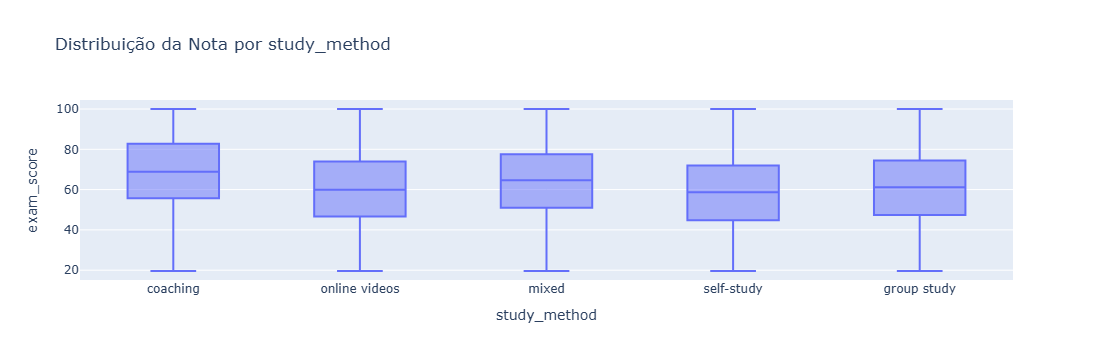

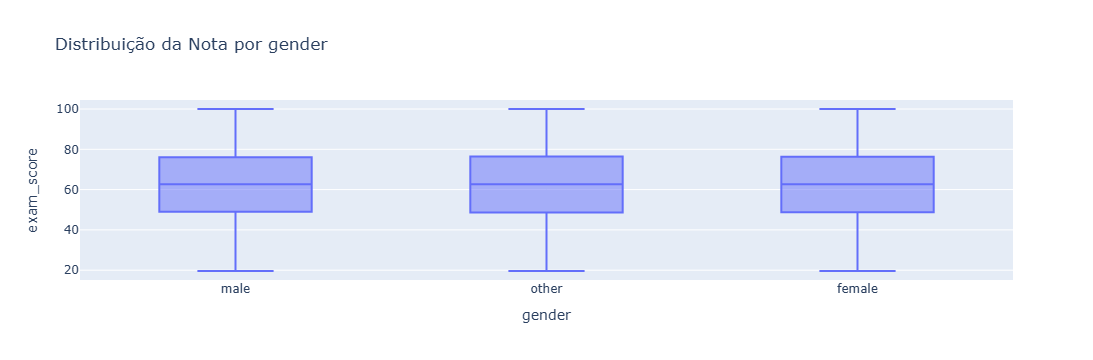

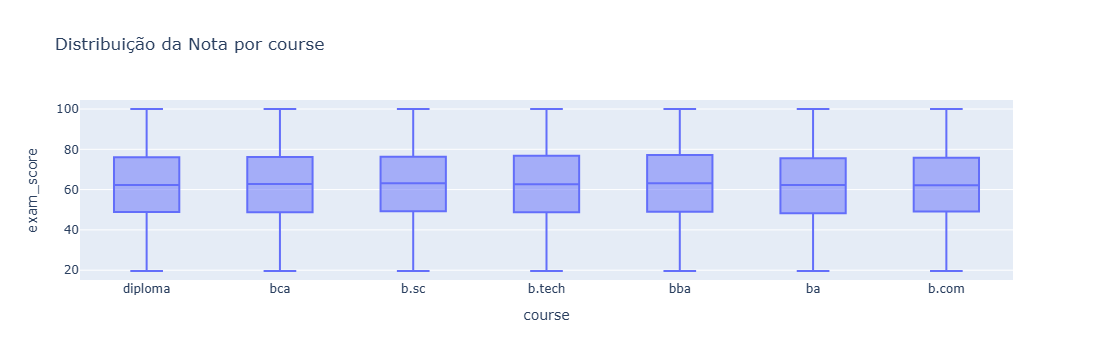

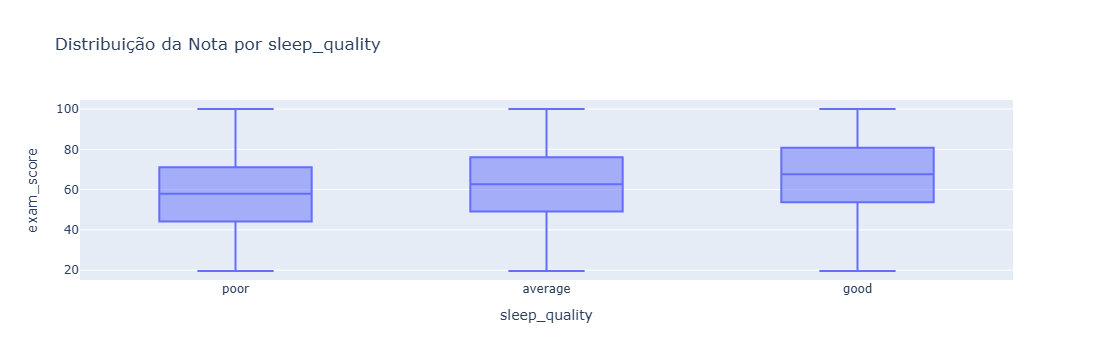

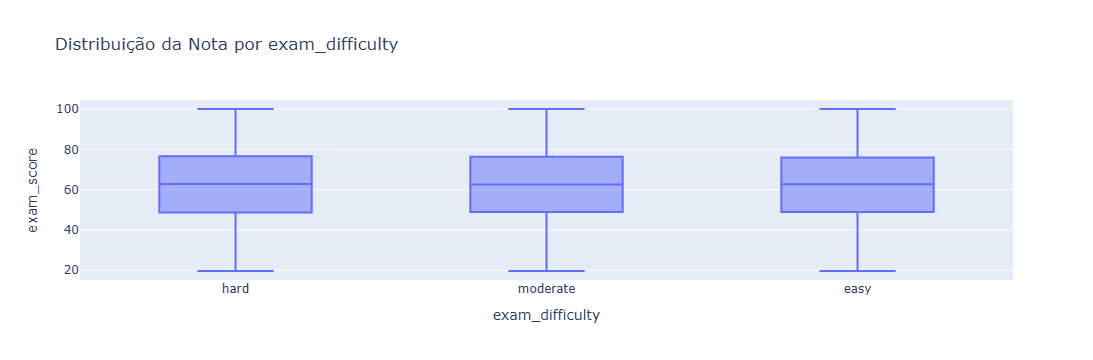

In [49]:
dummies = ["study_method", "gender", "course", "sleep_quality", "exam_difficulty"]

for coluna in dummies:
    grafico = px.box(tabela, x=coluna, y="exam_score", title=f"Distribuição da Nota por {coluna}")
    grafico.show()
